# Rozdzielczość obrazu. Interpolacja.

## Cel zajęć:

* zapoznanie z pojęciem rozdzielczości przestrzennej (rozmiaru obrazu),
* metody interpolacji najbliższego sąsiada oraz dwuliniowa,
* zapoznanie z pojęciem rozdzielczości dpi (ang. dots per inch),
* zapoznanie z pojęciem rozdzielczości  poziomów jasności (dla obrazów w skali szarości),
* zadanie domowe: interpolacja dwusześcienna.

## Rozdzielczość przestrzenna

Dyskretna reprezentacja obrazu to zwykle macierz dwu (N x M - obraz w skali szarości) lub trójwymiarowa (N x M x 3 - obraz kolorowy).
Przez rozdzielczość przestrzenną rozumie się liczbę pikseli z których składa się obraz.
Przykładowo rozdzielczość VGA to  640 x 480, Full HD to 1920 x 1080, a 4K to 3840 x 2160.
Rozdzielczość obrazu można modyfikować (zwiększać/zmniejszać), co nazywa się skalowaniem obrazu.
Warto wiedzieć, że zwiększenie rozdzielczości obrazu nie zwiększa ilości informacji, a jedynie liczbę pikseli (w sensie "lepiej nie będzie").
Ponadto skalowanie zawsze wprowadza pewne zniekształcenia, nawet przy zmniejszaniu rozmiaru.

## Skalowanie bez interpolacji

Skalowanie bez interpolacji realizowane jest poprzez zastosowanie wprost wzoru definiującego:

\begin{equation*}
\begin{aligned}
x_{new} &= k_x * x_{old} \\
y_{new} &= k_y * y_{old}
\end{aligned}
\end{equation*}

1. Ładujemy potrzebne biblioteki, pobieramy obrazy z repozytorium, wczytujemy jeden z obrazów testowych (*chessboard.bmp*) i wyświetlamy go:

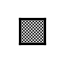

In [44]:
import cv2
import os
from matplotlib import pyplot as plt
import numpy as np
from urllib.request import urlretrieve

# Load required files
files = [
    ("parrot.bmp", "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/parrot.bmp"),
    ("clock.bmp", "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/clock.bmp"),
    ("chessboard.bmp", "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/chessboard.bmp"),
    ("lena.bmp", "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/lena.bmp"),
    ("firetruck.jpg", "https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/firetruck.jpg"),
]

for filename, url in files:
    if not os.path.exists(filename):
        urlretrieve(url, filename)

I = cv2.imread('chessboard.bmp')           # Read image
I = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY) # Convert to RGB

# Display
plt.figure(figsize=(I.shape[0]/100,I.shape[1]/100), dpi=200)
plt.imshow(I, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()

2. Definiujemy funkcję do skalowania.

Jako argumenty wejściowe powinna ona przyjąć obraz oraz współczynniki skalowania w pionie i poziomie.
Wyjściem powinien być natomiast obraz w nowej rozdzielczości.
Wewnątrz należy:

* odczytać wymiary obrazka wejściowego,
* wyliczyć wymiary obrazka wyjściowego (tj. wymnożyć wymiary wejściowe przez skalę i zaokrąglić do liczb całkowitych),
* utworzyć nowy obraz o ww. rozmiarze,
* w pętli po starym obrazie, dla każdego piksela, wykorzystując współczynniki skalowania, wyznaczyć miejsce zapisu piksela w nowym obrazie.


In [45]:
# TODO: Do samodzielnej implementacji
def scale_image(image, kx, ky):
    height, width = image.shape
    new_height = int(height * ky)
    new_width = int(width * kx)
    out_image = np.zeros((new_width, new_height), dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            sx = int(i*kx)
            ex = int((i+1)*kx)
            sy = int(j*ky)
            ey = int((j+1)*ky)
            out_image[sx:ex, sy:ey] = image[i, j]

    return out_image

3. Testujemy stworzoną funkcję:
    * dla skali 1.0, 1.0 i obrazka *chessboard*,
    * dla 3.0, 2.0 i tego samego obrazka,
    * dla skal mniejszych od 1.

Uwaga: proszę dla powyższych przypadków przygotować osobne sekcje kodu - tak, aby wyświetlały się wszystkie rozważane przypadki.

Czy zaimplementowana metoda nadaje się do sensownego skalowania obrazów?

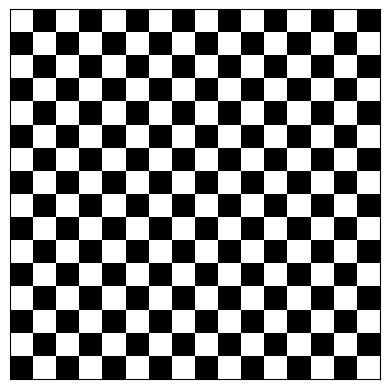

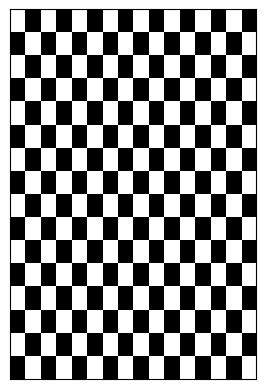

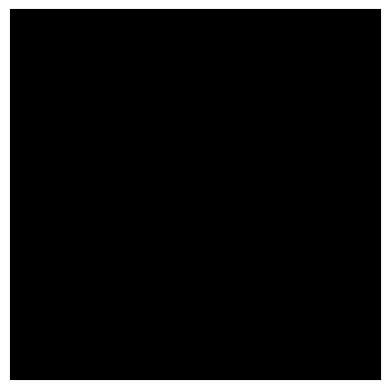

In [46]:
chess = cv2.imread('chessboard.bmp')           # Read image
chess = cv2.cvtColor(chess, cv2.COLOR_BGR2GRAY) # Convert to RGB
out1 = scale_image(chess, 1, 1)
out2 = scale_image(chess, 3, 2)
out3 = scale_image(chess, 0.5, 0.5)
# Display
plt.figure()
plt.imshow(out1, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out2, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out3, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()



Nie nadaję sie do sensownego skalowania obrazu, ponieważ dla skali mniejszych niż 1 wyniki są absolutnie niepodobne do wyjściowego obrazu.

## Skalowanie z interpolacją

W ramach niniejszego ćwiczenia zapoznamy się z metodami interpolacji, które są podstawą takich operacji jak: przybliżanie (zoom), zmiana rozdzielczości, rotacja obrazu, czy też korekcje geometryczne.
Jako przykład posłuży nam zmiana rozdzielczości, czyli inaczej mówiąc przepróbkowanie obrazu.
Dla przypomnienia - interpolacja to wykorzystanie znanych danych (wartości dla tzw. punktów węzłowych) do określania wartości w nieznanych lokalizacjach.

Zacznijmy od prostego przykładu.
Mamy obraz o rozdzielczości 500 x 500 pikseli, a chcemy go powiększyć do 750 x 750 pikseli -- tj. o~współczynnik 1,5.
Wyobraźmy sobie zatem, że dysponujemy siatką 750 x 750 o takim samym "rozmiarze" pojedynczego piksela jak obraz oryginalny.
Następnie siatkę tą ,,ścieśniamy'', tak aby miała rozmiar 500 x 500.
W rezultacie otrzymana siatka będzie miała mniejszy rozmiar pojedynczego piksela niż obraz oryginalny.
Schematycznie przedstawiono to na poniższym rysunku.

![Ilustracja interpolacji](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interEx57.png)


Pokazuje on przykład interpolacji: a) obraz 5x5, b) oraz 7x7, c) obraz 7x7 zmniejszony do 5x5.


Chcemy teraz poszczególnym elementom nowej siatki przyporządkować piksele z obrazu wejściowego.
Jedną z możliwości jest poszukanie "najbliższego" piksela w oryginalnym obrazie i wzięcie jego wartości.
Przykład takiego postępowania zaprezentowano na  poniższym rysunku.

![Ilustracja najbliższego sąsiada](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/inteNNEx.png)

Kilka słów wyjasnienia.
Kolorem ciemnoszarym oznaczono siatkę 5x5, a czarnym 7x7 (już po przeskalowaniu).
Nasze zadanie sprowadza się do znalezienia dla każdej kropki czarnej (umowny środek piksela), najbliżej leżącej kropki szarej - oznaczono to dla pierwszych trzech wierzszy obrazu liniami.

Po zrealizowaniu powyższego kroku dla całego obrazu wykonujemy "rozciągniecie" do rozdzielczości 750 x 750.
W ten sposób uzyskujemy finalny efekt zmiany rozdzielczości.

## Interpolacja metodą najbliższego sąsiada

Takie postępowanie określa się mianem **interpolacji metodą najbliższego sąsiada** (ang. *nearest neighbour interpolation*).
W ramach pierwszego etapu ćwiczenia zaimplementujemy to podejście.

1. Wczytujemy jeden z obrazów testowych (*parrot.bmp*) i wyświetlamy go:

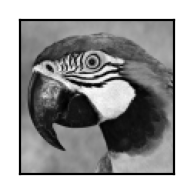

In [47]:
parrot = cv2.imread('parrot.bmp')           # Read image
parrot = cv2.cvtColor(parrot, cv2.COLOR_BGR2GRAY) # Convert to RGB

# Display
plt.figure(figsize=(parrot.shape[0]/100,parrot.shape[1]/100), dpi=200)
plt.imshow(parrot, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()

2. Definiujemy funkcję do interpolacji metodą najbliższego sąsiada.

Jako argumenty wejściowe powinna ona przyjąć obraz oraz współczynniki skalowania w pionie i poziomie.
Wyjściem powinien być natomiast obraz w nowej rozdzielczości.
Wewnątrz należy:

* odczytać wymiary obrazka wejściowego,
* wyliczyć wymiary obrazka wyjściowego (tj. wymnożyć wymiary wejściowe przez skalę i zaokrąglić do liczb całkowitych),
* utworzyć nowy obraz o ww. rozmiarze,
* w pętli po nowym obrazie, dla każdego piksela, wykorzystując współczynniki skalowania, odnaleźć najbliższego sąsiada.




In [48]:
# TODO: Do samodzielnej implementacji

def interpolation_nearest_neighbour(image,kx,ky):
    height, width = image.shape
    new_height = int(height * ky)
    new_width = int(width * kx)
    out_image = np.zeros((new_height, new_width), dtype=np.uint8)
    
    for i in range(new_height):
        for j in range(new_width):
            if int(np.round(i/ky)) < height and int(np.round(j/kx)) < width:
                out_image[i, j] = image[int(np.round(i/ky)), int(np.round(j/kx))]
    return out_image

3. Testujemy stworzoną funkcję:
    * dla skali 1.5, 1.5 i obrazka *parrot*,
    * dla 2.5, 2.5 - tu okaże się, że do kodu trzeba dopisać zabezpieczenie przed wyjściem poza zakres,
    * dla niejednakowych skal np. 1.5 i 2.5,
    * dla skal mniejszych od 1,
    * dla niesymetrycznego obrazka *clock*,
    * dla obrazka z szachownicą *chessboard*.

Uwaga: proszę dla powyższych przypadków przygotować osobne sekcje kodu - tak, aby wyświetlały się wszystkie rozważane przypadki.

Wykonana metoda jest bardzo prosta i szybka, ale wprowadza pewne niepożądane artefakty, w szczególnie źle odwzorowane są linie proste.
Z drugiej strony sprawdza się w pewnych nietypowych przypadkach.
Zostanie to zademonstrowane w dalszej części ćwiczenia.

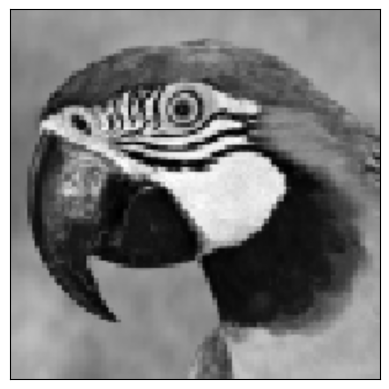

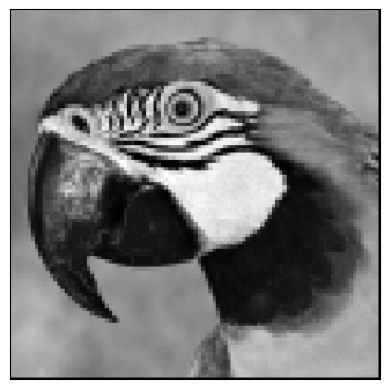

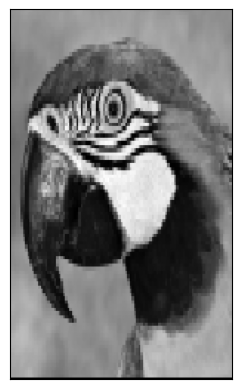

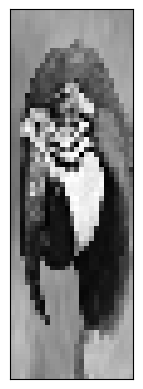

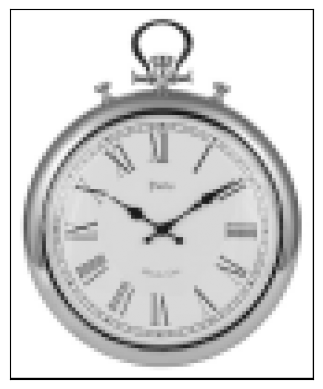

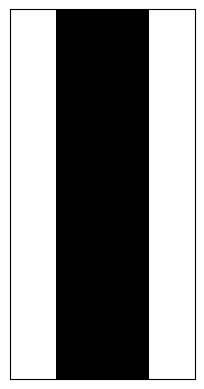

In [49]:
# TODO: Do samodzielnej implemetantacji
out1515 = interpolation_nearest_neighbour(parrot, 1.5, 1.5)
out2525 = interpolation_nearest_neighbour(parrot, 2.5, 2.5)
out1525 = interpolation_nearest_neighbour(parrot, 1.5, 2.5)
out0505 = interpolation_nearest_neighbour(parrot, 0.25, 0.75)
clock = cv2.imread('clock.bmp')           # Read image
clock = cv2.cvtColor(clock, cv2.COLOR_BGR2GRAY) 
out_clock = interpolation_nearest_neighbour(clock, 3, 3)
outchess = interpolation_nearest_neighbour(chess, 0.3, 0.5)
# Display
plt.figure()
plt.imshow(out1515, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out2525, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out1525, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out0505, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(out_clock, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()
plt.figure()
plt.imshow(outchess, cmap ="gray")
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x
plt.show()



## Interpolacja dwuliniowa

W praktyce, lepszym rozwiązaniem zwykle okazuje tzw. **interpolacja dwuliniowa** (ang. *bilinear interpolation*).
Wykorzystuje ona informację o czterech najbliższych sąsiadach do określenia nowej wartości piksela.

Jeśli przez $(i,j)$ oznaczymy współrzędne poszukiwanego piksela, a przez $I(i,j)$ jego jasność (składową w~odcieniach szarości) to jego wartość można obliczyć wykorzystując równanie:
\begin{equation}
I(i,j) = a \cdot i + b \cdot j+ c \cdot i \cdot j + d
\tag{1}
\end{equation}
gdzie: współczynniki $a,b,c,d$ można wyliczyć na podstawie czterech najbliższych sąsiadów.

![Ilustracja dwuliniowej](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interABCD.png)

Prześledźmy to na przykładzie z powyższego rysunku.
Niech współrzędne poszczególnych punktów to $A = (j_1,i_1)$, $B = (j_1,i_2)$, $C= (j_2,i_2)$ oraz $D = (j_2,i_1)$.
W pierwszej kolejności dokonujemy interpolacji wartości w punktach $AB$ i $CD$ -- czyli poziomo.
Wychodząc od równania prostej otrzymujemy:

\begin{equation}
f(AB) \approx \frac{i_2 - i}{i_2-i_1}f(A) + \frac{i - i_1}{i_2-i_1}f(B)
\tag{2}
\end{equation}

\begin{equation}
f(CD) \approx \frac{i_2 - i}{i_2-i_1}f(D) + \frac{i - i_1}{i_2-i_1}f(C)
\tag{3}
\end{equation}

Następnie wykonujemy analogiczną interpolację w pionie:
\begin{equation}
f(ABCD) \approx \frac{j_2 - j}{j_2-j_1}f(AB) + \frac{j - j_1}{j_2-j_1}f(CD)
\tag{4}
\end{equation}

Łącząc powyższe równania otrzymujemy:
\begin{equation}
f(ABCD) \approx \frac{1}{(i_2 - i_1)(j_2-j_1)} ( f(A)(i_2-i)(j_2 - y) + f(B)(i-i_1)(j_2 - j) \\ + f(C)(i-i_1)(j-j_1) + f(D)(i_2-i)(j-j_1))
\tag{5}
\end{equation}
gdzie zapis $f(X)$ oznacza wartość piksela w punkcie $X$.

Rozważania można uprościć przyjmując, że narożniki rozpatrywanego kwadratu mają następujące współrzędne: $A = (0,0)$, $B = (0,1)$, $C= (1,1)$ oraz $D = (1,0)$.
Wtedy powyższe równanie można zapisać:
\begin{equation}
f(ABCD) \approx f(A)(1-i)(1-j) + f(B)i(1-j) + f(C)ij + f(D)(1-i)j
\tag{6}
\end{equation}

lub macierzowo:
\begin{equation}
f(ABCD) \approx \begin{bmatrix}1 - i & i \end{bmatrix} \begin{bmatrix} f(A) & f(D) \\\\ f(B) & f(C)  \end{bmatrix}   \begin{bmatrix} 1-j \\\\ j  \end{bmatrix}
\tag{7}
\end{equation}

Uwaga.
Nieco wbrew nazwie interpolacja dwuliniowa nie jest operacją liniową.
W złożeniu dwóch operacji liniowych pojawia się człon $xy$.

Warto dodać, że kolejny ``poziom wtajemniczenia'' to **interpolacja dwusześcienna** (ang. *bicubic interpolation*).
Dana jest ona wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\tag{8}
\end{equation}
Jej implementacja stanowi zadanie domowe do bieżącego ćwiczenia.

Trzy powyżej przedstawione metody bynajmniej nie wyczerpują tematu.
Wystarczy choćby otworzyć stronę [wiki o skalowaniu](https://en.wikipedia.org/wiki/Image_scaling), by zobaczyć, że metod jest dużo więcej.



Wykorzystując powyższe równania zaimplementuj interpolację dwuliniową:
* dobrym punktem wyjścia będzie stworzona funkcja do interpolacji metodą najbliższego sąsiada,
* początek powinien być identyczny,
* różnice rozpoczynają się w momencie obliczenia współrzędnych nowego piksela,
* jeśli chcemy zastosować opisane powyżej wzory (w wariancie uproszczonym), to musimy wyliczyć współrzędne punktów $A,B,C,D$,
* w pierwszym kroku obliczamy współrzędne $A$ tj. $(0,0)$ - należy do tego wykorzystać funkcję *floor* (np. $i_1 = floor(i / h_{scale})$).
  Proszę ten krok odnieść do przedstawionego rysunku poglądowego,
* obliczenie współrzędnych $B,C,D$ jest już proste i sprowadza się do operacji `+1`,
* potrzebujemy jeszcze część ułamkową współrzędnych punktu $ABCD$ tj. $(i,j)$ - od ilorazu $i/h_{scale}$ należy odjąć wartość $i_1$
* wykorzystując wyznaczone współrzędne, należy pobrać wartości jasności w punktach $A,B,C,D$, tj. $f(A),f(B),f(C),f(D)$, podstawić do odpowiedniego równania i wykonać interpolację.

  Uwagi:
* Tworzenie macierzy *np.array*, mnożenie macierzy *np.dot*. Przy tworzeniu macierzy proszę zwrócić uwagę na niezbędne nawiasy kwadratowe.
* Przy próbie uruchomienia kodu pewnie okaże się, że wystąpi przekroczenie zakresu - należy dodać stosowne zabezpieczenie.

Proszę dla interpolacji dwuliniowej wykonać takie same eksperymenty, jak dla  najbliższego sąsiada.




In [50]:
# TODO: Do samodzielnej implemetantacji

import numpy as np

def interpolation_bilinear(image, kx, ky):
    height, width = image.shape
    new_height = int(height * ky)
    new_width = int(width * kx)
    
    out_image = np.zeros((new_height, new_width), dtype=np.uint8)
    
    for i in range(new_height):
        for j in range(new_width):
            
            x = i / ky
            y = j / kx
            
            i1 = int(np.floor(x))
            j1 = int(np.floor(y))
            
            i2 = i1 + 1
            j2 = j1 + 1
            
            if i2 >= height:
                i2 = height - 1
            if j2 >= width:
                j2 = width - 1
            
            dx = x - i1
            dy = y - j1
            
            A = image[i1, j1]
            B = image[i1, j2]
            C = image[i2, j2]
            D = image[i2, j1]
            
            value = (A * (1 - dx) * (1 - dy) +
                     B * (1 - dx) * dy +
                     C * dx * dy +
                     D * dx * (1 - dy))
            
            out_image[i, j] = np.clip(value, 0, 255)
    
    return out_image

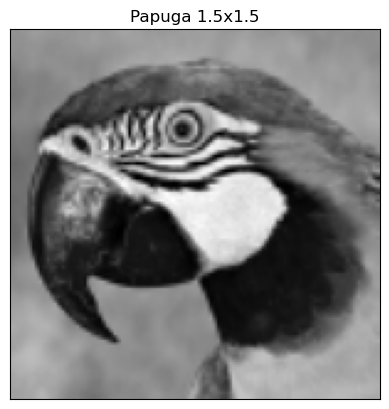

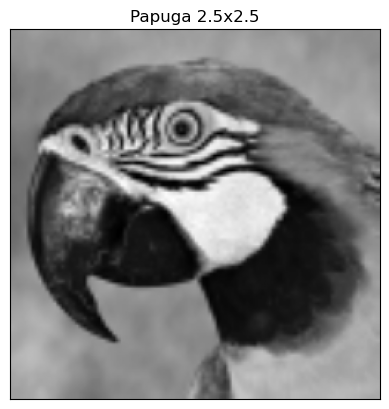

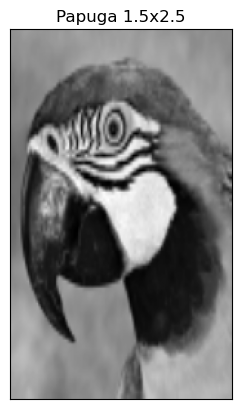

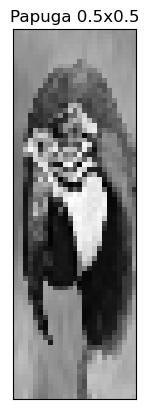

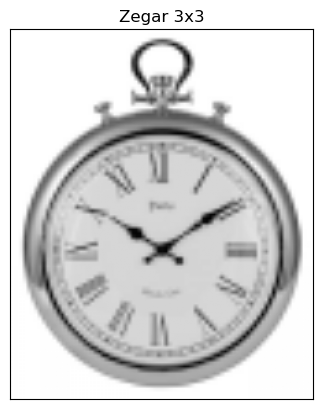

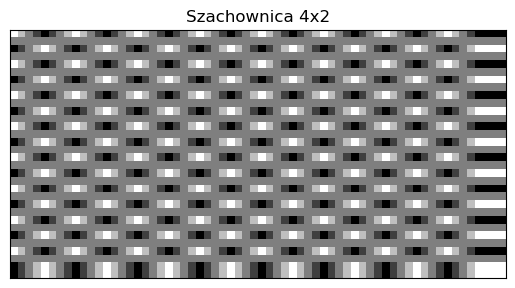

In [51]:
#TODO Do samodzielnej implementacji
out1515 = interpolation_bilinear(parrot, 1.5, 1.5)
out2525 = interpolation_bilinear(parrot, 2.5, 2.5)
out1525 = interpolation_bilinear(parrot, 1.5, 2.5)
out0505 = interpolation_bilinear(parrot, 0.25, 0.75)
clock = cv2.imread('clock.bmp')           # Read image
clock = cv2.cvtColor(clock, cv2.COLOR_BGR2GRAY) 
out_clock = interpolation_bilinear(clock, 3, 3)
outchess = interpolation_bilinear(chess, 4, 2)
# Display
plt.figure()
plt.title("Papuga 1.5x1.5")
plt.imshow(out1515, cmap ="gray")
plt.xticks([]), plt.yticks([])  
plt.show()
plt.figure()
plt.title("Papuga 2.5x2.5")
plt.imshow(out2525, cmap ="gray")
plt.xticks([]), plt.yticks([]) 
plt.show()
plt.figure()
plt.title("Papuga 1.5x2.5")
plt.imshow(out1525, cmap ="gray")
plt.xticks([]), plt.yticks([])  
plt.show()
plt.figure()
plt.title("Papuga 0.5x0.5")
plt.imshow(out0505, cmap ="gray")
plt.xticks([]), plt.yticks([])  
plt.show()
plt.figure()
plt.title("Zegar 3x3")
plt.imshow(out_clock, cmap ="gray")
plt.xticks([]), plt.yticks([])  
plt.show()
plt.figure()
plt.title("Szachownica 4x2")

plt.imshow(outchess, cmap ="gray")
plt.xticks([]), plt.yticks([])  
plt.show()




## Interpolacja w OpenCV

W OpenCV dostępna jest funkcja `resize`, która służy do zmiany rozmiaru obrazka.
Składnia jest następująca `dst = cv2.resize(	src, dsize[, dst[, fx[, fy[, interpolation]]]] )`, gdzie `det` to obraz wynikowy, `src` obraz źródłowy, `dsize` rozmiar docelowy (ew. można podać współczynniki skalowania dla poszczególnych osi: `fx,fy`), `interpolation` metoda interpolacji.
Metod podstawowych dostępnych jest 5:
- najbliższego sąsiada - ` cv2.INTER_NEAREST`,
- dwuliniowa - ` cv2.INTER_LINEAR`,
- dwukubiczna - ` cv2.INTER_CUBIC`,
- *area* - ` cv2.INTER_AREA`,
- *lanczos4* - ` cv2.INTER_LANCZOS4`.

Przeprowadzimy następujący eksperyment: obraz (o większej niż dotąd rozdzielczości) przeskalujemy każdą z metod -- zwiększymy i zmniejszymy jego rozdzielczość. Dodamy też pomiar czasu realizacji obliczeń.

Obraz: `firetruck.jpg`


Proszę stworzyć funkcję, która jako argumenty przyjmuje obraz oraz dwa współczynniki skalujące, a wewnątrz przeprowadzone zostaną interpolacje, pomiar czasu oraz wizualizacja (można wypisać czas w tytule rysunku).

Pomiar czasu:
```{python}
from timeit import default_timer as timer
start = timer()
# ...
end = timer()
print(end - start)
```

Wykonaj eksperyment dla współczynników skalowanie równychk `(3.5,4.5)`, przeanalizuj czasy obliczeń.

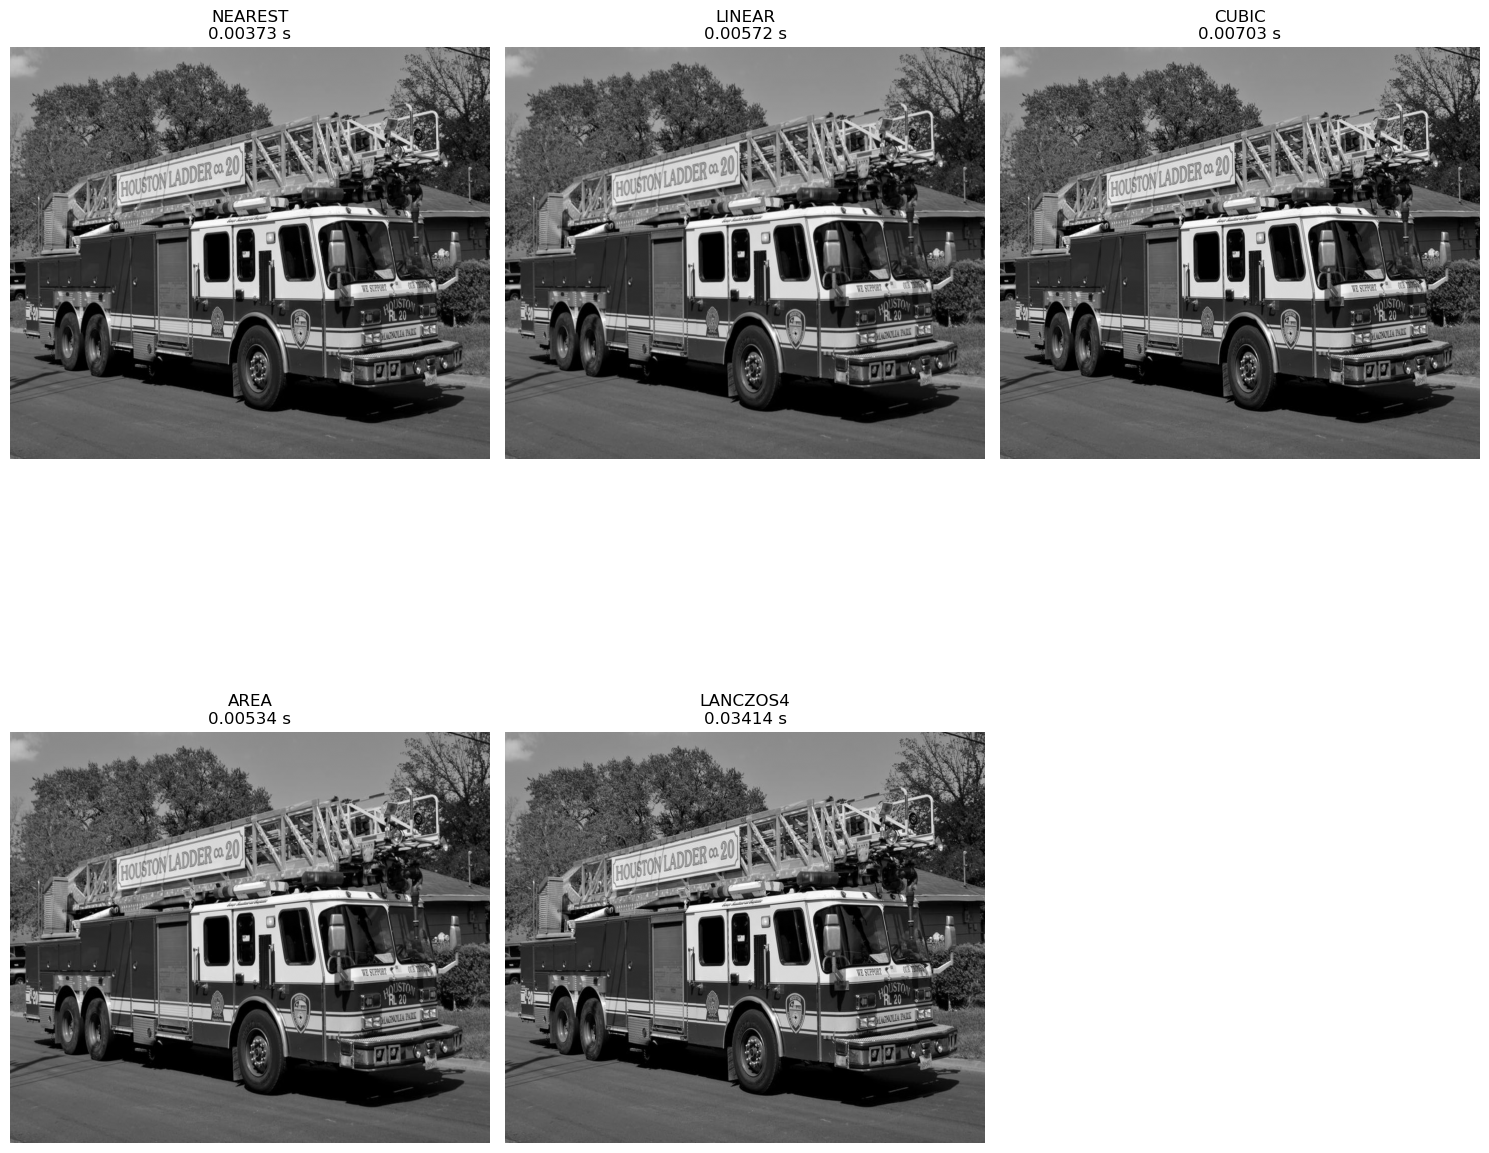

{'NEAREST': 0.0037271000001055654, 'LINEAR': 0.0057236999991800985, 'CUBIC': 0.007032399999843619, 'AREA': 0.005343999999240623, 'LANCZOS4': 0.03413540000019566}


In [ ]:
from timeit import default_timer as timer

def test_interpolations(image, kx, ky):
    methods = {
        "NEAREST": cv2.INTER_NEAREST,
        "LINEAR": cv2.INTER_LINEAR,
        "CUBIC": cv2.INTER_CUBIC,
        "AREA": cv2.INTER_AREA,
        "LANCZOS4": cv2.INTER_LANCZOS4
    }
    
    results = {}
    times = {}
    
    for name, method in methods.items():
        start = timer()
        
        resized = cv2.resize(image, None, fx=kx, fy=ky, interpolation=method)
        
        end = timer()
        
        results[name] = resized
        times[name] = end - start
    
    plt.figure(figsize=(15, 15))
    
    for i, (name, img) in enumerate(results.items()):
        plt.subplot(2, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{name}\n{times[name]:.5f} s")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return times

img = cv2.imread("firetruck.jpg", 0)  

times = test_interpolations(img, 3.5, 4.5)

print(times)

## Rozdzielczość (dpi)

Omówioną wcześniej rozdzielczość przestrzenną (rozmiar) należy utożsamiać z rozmiarem macierzy w której zapisany jest obraz.
W tym ujęciu rozmiar pojedynczego piksela nie ma specjalnego znaczenia.
Problem pojawia się, kiedy obraz trzeba wyświetlić lub wydrukować.
Wtedy pojedynczy piksel staje się ,,obiektem fizycznym'' i musi mieć swój rozmiar (wysokość/szerokość/powierzchnię).

Parametr dpi (ang. *dots per inch*) określa liczbę kropek (pikseli), która mieści się na jednym calu (25,4 mm) długości/szerokości.
Dopiero kombinacja rozmiaru i rozdzielczości określa nam rzeczywisty rozmiar obrazu jaki uzyskamy na wydruku.

Dpi staje się istotne w przypadku drukowania, gdyż wyświetlanie na monitorze odbywa się zazwyczaj 1 piksel obrazka = 1 piksel na monitorze (w przypadku maksymalnej rozdzielczości wspieranej przez monitor), ew. następuje automatyczne skalowanie.

Wpływ rozdzielczości można zademonstrować w następujący sposób:
- wczytaj obraz *lena.bmp*.  Ma on rozmiar $512 \times 512$.
- wykorzystując funkcję `imresize` stwórz obrazy o rozmiarach $256 \times 256$, $128 \times 128$, $64 \times 64$ - metoda interpolacji jest w tym wypadku mniej istotna.
- wyświetl obrazy wymuszając zachowanie na ekranie wejściowej rozdzielczości $512 \times 512$. W przypadku biblioteki *matplotlib* ta funkcjonalność jest domyślna.

Proszę zaobserwować co dzieję się z obrazkiem.

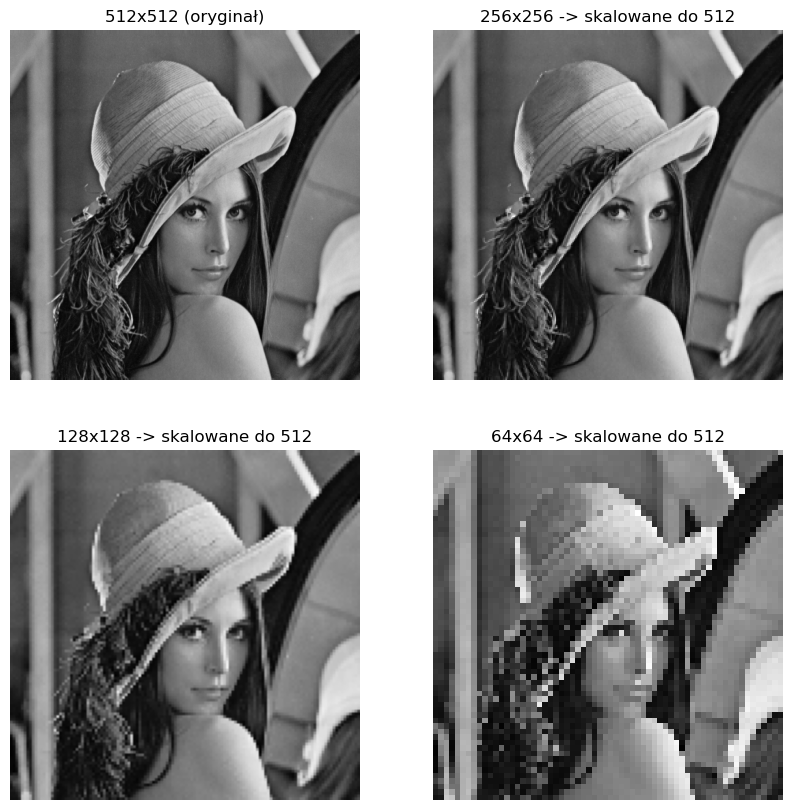

In [56]:
#TODO Porównanie

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("lena.bmp", 0)

img_256 = cv2.resize(img, (256, 256))
img_128 = cv2.resize(img, (128, 128))
img_64  = cv2.resize(img, (64, 64))

plt.figure(figsize=(10, 10))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("512x512 (oryginał)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_256, cmap='gray')
plt.title("256x256 -> skalowane do 512")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_128, cmap='gray')
plt.title("128x128 -> skalowane do 512")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_64, cmap='gray')
plt.title("64x64 -> skalowane do 512")
plt.axis('off')

plt.show()

## Liczba poziomów jasności

Dla obrazów w skali szarości pojedynczy piksel zwykle zapisuje się na 8 bitach, co daje 256 rozróżnialnych poziomów szarości.
Dla większości zastosowań wartość ta jest wystarczająca (choć są kamery o wyjścu 12 lub 16 bitów).
Jednak oko ludzkie nie potrafi rozróżnić wszystkich 256 poziomów jasności (jest za mało czułe).
Zazwyczaj człowiek rozróżnia 20-30 poziomów szarości (to ile i jakie dokładnie rozróżnia, zależy od konkretnego oświetlenia sceny i cech osobniczych).

W poniższych krokach zademonstrujemy omówione zjawisko:
- wczytaj (użyj) obrazu _lena_,
- wykorzystując znaną funkcję `normalize` zmień liczbę poziomów szarości z 0-255 na:
    * 0-31
    * 0-15
    * 0-7
    * 0-3
    * 0-1 (binaryzacja)
- rezultaty wyświetl na wspólnym rysunku.

Podpowiedzi:
- trzeba przygotować tablice na obrazki np, `I_31 = np.zeros(I.shape,'uint8')`,
- prawidłowe użycie funkcji normalize `cv2.normalize(I,I_31,0,31,cv2.NORM_MINMAX)`,
- przykładowe wyświetlanie `axsHist[0,1].imshow(I, 'gray', vmin=0, vmax=31)`.

Czy rezultaty eksperymentu pasują do teorii o rozpoznawaniu przez człowieka ograniczonego zakresu poziomów jasności?
Wizualne porównanie których obrazów o tym świadczy ?

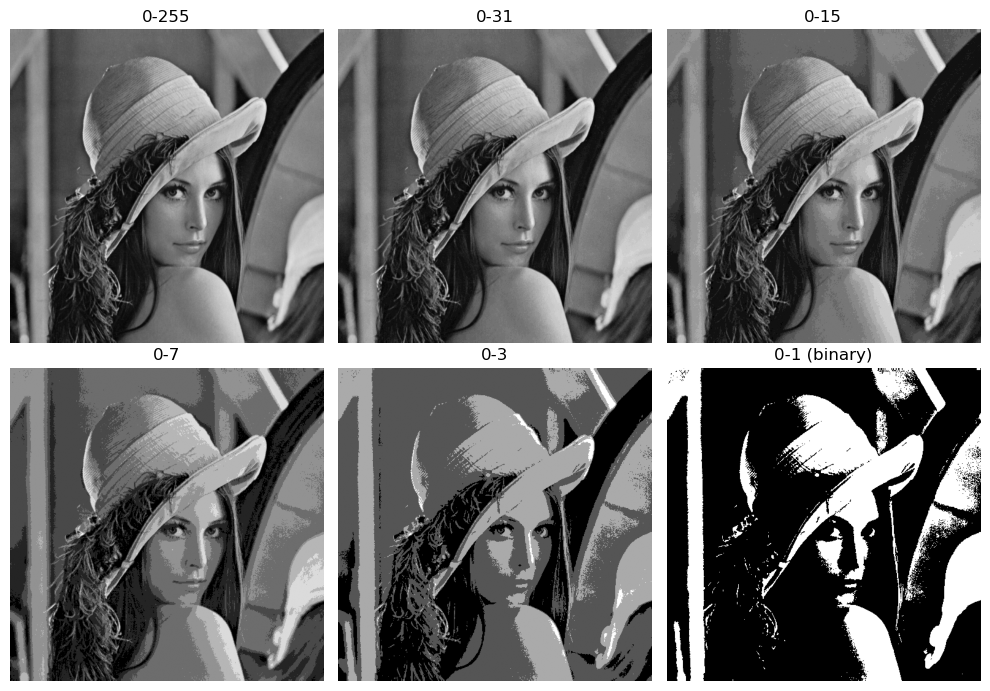

In [57]:
I = cv2.imread('lena.bmp')
I = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)

I_31 = np.zeros(I.shape, 'uint8')
I_15 = np.zeros(I.shape, 'uint8')
I_7  = np.zeros(I.shape, 'uint8')
I_3  = np.zeros(I.shape, 'uint8')
I_1  = np.zeros(I.shape, 'uint8')

# normalizacja (zmiana liczby poziomów)
cv2.normalize(I, I_31, 0, 31, cv2.NORM_MINMAX)
cv2.normalize(I, I_15, 0, 15, cv2.NORM_MINMAX)
cv2.normalize(I, I_7,  0, 7,  cv2.NORM_MINMAX)
cv2.normalize(I, I_3,  0, 3,  cv2.NORM_MINMAX)
cv2.normalize(I, I_1,  0, 1,  cv2.NORM_MINMAX)

# wyświetlanie
fig, axs = plt.subplots(2, 3, figsize=(10, 7))

axs[0,0].imshow(I, cmap='gray')
axs[0,0].set_title("0-255")
axs[0,0].axis('off')

axs[0,1].imshow(I_31, cmap='gray', vmin=0, vmax=31)
axs[0,1].set_title("0-31")
axs[0,1].axis('off')

axs[0,2].imshow(I_15, cmap='gray', vmin=0, vmax=15)
axs[0,2].set_title("0-15")
axs[0,2].axis('off')

axs[1,0].imshow(I_7, cmap='gray', vmin=0, vmax=7)
axs[1,0].set_title("0-7")
axs[1,0].axis('off')

axs[1,1].imshow(I_3, cmap='gray', vmin=0, vmax=3)
axs[1,1].set_title("0-3")
axs[1,1].axis('off')

axs[1,2].imshow(I_1, cmap='gray', vmin=0, vmax=1)
axs[1,2].set_title("0-1 (binary)")
axs[1,2].axis('off')

plt.tight_layout()
plt.show()

